# Au [100] Verification: Multislice vs WPM vs KG ODE

Thickness sweep for Au [100] comparing five propagation methods against
paper reference data from **Rother & Scheerschmidt 2009** (doi:10.1016/j.ultramic.2008.08.008).

**Methods**: Fresnel MS, Angular Spectrum MS, WPM, Full KG ODE, KG FWD Lanczos

**Parameters**: Au FCC, a = 4.08 Å, 300 keV, 128×128×128 sampling,
Weickenmeier-Kohl parametrization for KG methods, Lobato for MS/WPM.

In [1]:
%matplotlib inline

import os
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".1"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import functools
from ase.build import bulk
from scipy.interpolate import interp1d
from scipy.special import erfc as scipy_erfc
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
)
from wide_angle_propagation.propagation_methods import (
    beam_amplitudes_fwd_direct_allbeams,
    _lanczos_expsqrt,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape
    C = np.fft.fft2(psi_xy) / (Nx * Ny)
    if use_fftshift:
        C = np.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return np.abs(C[cy + k, cx + h])
    else:
        return np.abs(C[k % Ny, h % Nx])

## Paper reference data

Extracted beam amplitude curves from Figure 3 of Rother & Scheerschmidt 2009.

In [2]:
raw_data_Au_Beam_0_0_Klein_Gordon_MS = """0.06421232876712413, 0.9984732824427482
0.98458904109589, 0.9874045801526719
1.9049657534246576, 0.9599236641221375
2.397260273972603, 0.9431297709923665
3.4460616438356153, 0.9041984732824428
4.216609589041096, 0.8809160305343512
4.880136986301369, 0.867557251908397
5.736301369863013, 0.8641221374045802
6.6138698630137, 0.8725190839694656
7.4486301369863, 0.8858778625954199
8.197773972602743, 0.9022900763358779
8.94691780821918, 0.918320610687023
9.76027397260274, 0.9286259541984734
10.637842465753426, 0.9324427480916031
11.665239726027401, 0.9240458015267177
12.671232876712331, 0.9041984732824428
13.613013698630137, 0.8809160305343513
14.511986301369863, 0.8595419847328245
15.325342465753433, 0.8450381679389314
16.438356164383563, 0.835496183206107
17.529965753424662, 0.8381679389312977
18.728595890410965, 0.8461832061068704
19.58476027397261, 0.8515267175572521
20.71917808219178, 0.8530534351145038
21.72517123287672, 0.8473282442748091
23.073630136986306, 0.8297709923664123
24.14383561643836, 0.8118320610687024
24.807363013698637, 0.8030534351145039"""

raw_data_Au_Beam_0_28_Klein_Gordon_FWD = """0.22062721060899548, 0.00022950819672130918
0.7942772332571906, 0.000852459016393449
1.500467420321705, 0.0018360655737704942
2.339342334788604, 0.0033770491803278707
3.0016335617428496, 0.004622950819672133
4.680202580931187, 0.008819672131147538
5.828562754792266, 0.011508196721311474
7.373218261196406, 0.013475409836065575
8.475824249959047, 0.013901639344262293
9.798479197386307, 0.013770491803278686
10.768593209394673, 0.013901639344262293
11.915700504042945, 0.014885245901639345
12.908872312333159, 0.01639344262295082
14.41020711057142, 0.01940983606557377
15.05035610682242, 0.020524590163934424
16.373974807490292, 0.02170491803278688
18.093647902391076, 0.02183606557377049
19.32792667765346, 0.02144262295081967
21.35669953065218, 0.02219672131147541
22.901379130887335, 0.024196721311475405
24.0047802160735, 0.02570491803278688
24.93111573712666, 0.02626229508196721"""

raw_data_Au_Beam_0_28_Klein_Gordon_MS = """0.06620984763060989, 0.00009836065573769898
0.8162989948053649, 0.0008196721311475447
1.478421564942515, 0.0018360655737704873
2.9133055772400027, 0.0044262295081967246
5.253876697410391, 0.009475409836065572
6.732466919170015, 0.011540983606557375
8.12178949701719, 0.012131147540983607
9.796937192201312, 0.011672131147540982
11.870355914071766, 0.013180327868852457
13.613857807846884, 0.015737704918032787
14.606836865488965, 0.016983606557377046
15.841790268019778, 0.017508196721311473
16.76733069264946, 0.016983606557377046
18.177205308352853, 0.015540983606557375
19.939813610123274, 0.014098360655737704
22.034724029259564, 0.01485245901639344
23.071144264222596, 0.015213114754098356
24.0765157236341217, 0.015081967213114753
24.92234558263702, 0.014327868852459017"""

def parse_and_interpolate(raw_data):
    data = np.array([[float(val) for val in line.split(',')] for line in raw_data.strip().split('\n')])
    data = data[data[:, 0].argsort()]
    return interp1d(data[:, 0], data[:, 1], kind='linear', fill_value="extrapolate")

Beam_0_0_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_0_Klein_Gordon_MS)
Beam_0_28_Au_Klein_Gordon_FWD = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_FWD)
Beam_0_28_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_MS)
print("Paper reference curves loaded.")

Paper reference curves loaded.


## Crystal setup and Weickenmeier-Kohl parametrization

Au FCC, a = 4.076 Å, 128 slices/cell, no thermal motion.
WK parametrization for forward KG methods to match paper.

In [3]:
from abtem.parametrizations import Parametrization

def weickenmeier_kohl_function(k2, parameters):
    A, B = parameters
    s2 = k2 / 4.0
    s2_expanded = s2[..., None]
    term = -np.expm1(-B * s2_expanded)
    sum_term = np.sum(A * term, axis=-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_s = sum_term / s2
    limit_val = np.sum(A * B)
    f_s = np.where(s2 == 0, limit_val, f_s)
    return f_s * 47.87801

def weickenmeier_kohl_potential(r, parameters):
    A, B = parameters
    r = np.asarray(r, dtype=np.float64)
    result = np.zeros_like(r)
    for i in range(len(A)):
        result += A[i] * scipy_erfc(2 * np.pi * r / np.sqrt(B[i]))
    with np.errstate(divide='ignore', invalid='ignore'):
        V = 47.87801 * 4 * np.pi * result / r
    V = np.where(r < 1e-14, 1e30, V)
    return V

class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            'elastic': weickenmeier_kohl_function,
            'projected_scattering_factor': weickenmeier_kohl_function,
            'potential': weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if "Au" not in symbol:
            raise NotImplementedError("Only Au is implemented.")
        Z = 79
        V = 0.4
        B = np.array([5.493e-01, 1.728e+00, 6.720e+00, 2.637e-02, 7.253e-02, 3.546e+01])
        factor = 0.02395 * Z
        a1_val = factor / (3 * (1 + V))
        A = np.array([a1_val, a1_val, a1_val, V * a1_val, V * a1_val, V * a1_val])
        return [A, B]

    def cutoff(self, symbol):
        return 20.0

# --- Crystal parameters ---
a_central = 4.076
n_slices_per_cell = 128
energy = 300e3
n_cells_range = range(0, 101)

atoms = bulk("Au", "fcc", a=a_central, cubic=True)
atoms.info['thermal_sigma'] = 0.0
atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

cell_thickness = atoms.get_cell()[2, 2]
slice_dz = cell_thickness / n_slices_per_cell

wk_param = WeickenmeierKohlParametrization()

# WK potential for KG methods
potential_wk = abtem.Potential(
    atoms, gpts=(128, 128), slice_thickness=slice_dz,
    projection="finite", parametrization=wk_param,
)
pot_array_wk = jnp.array(cupy.asnumpy(potential_wk.build(lazy=False).array / slice_dz))

# Lobato potential for MS/WPM methods
potential_lobato = abtem.Potential(
    atoms, gpts=(128, 128), slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
pot_array_lobato = jnp.array(cupy.asnumpy(potential_lobato.build(lazy=False).array / slice_dz))

# Plane wave and sampling
pw = abtem.PlaneWave(energy=energy)
pw.grid.match(potential_wk)
psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
sampling = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))
wavelength = energy2wavelength(energy)

print(f"Au FCC, a = {a_central} Å, {n_slices_per_cell} slices/cell")
print(f"dz = {slice_dz:.4f} Å, energy = {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Grid: 128×128, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")

Au FCC, a = 4.076 Å, 128 slices/cell
dz = 0.0318 Å, energy = 300 keV, λ = 0.0197 Å
Grid: 128×128, sampling = (0.0318, 0.0318) Å


## Thickness sweep — Fresnel MS, Angular Spectrum MS, WPM

Run the three paraxial/semi-paraxial methods through 0–25 unit cells using Lobato parametrization.

In [4]:
fk = jnp.array(fresnel_propagation_kernel(128, 128, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(128, 128, sampling, z=slice_dz, energy=energy))

keys = ["ms_00", "ms_028", "as_00", "as_028", "wpm_00", "wpm_028"]
results = {k: [] for k in keys}
w_ms, w_as, w_wpm = psi0, psi0, psi0

for i in tqdm(range(len(n_cells_range)), desc="MS/WPM sweep"):
    if i > 0:
        w_ms, _, _ = simulate_fresnel_as(pot_array_lobato, w_ms, fk, slice_dz, energy)
        w_as, _, _ = simulate_fresnel_as(pot_array_lobato, w_as, ak, slice_dz, energy)
        w_wpm, _, _ = simulate_wpm(pot_array_lobato, w_wpm, slice_dz, energy, sampling)
        w_ms = jnp.array(w_ms)
        w_as = jnp.array(w_as)
        w_wpm = jnp.array(w_wpm)

    results["ms_00"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 0))
    results["ms_028"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 28))
    results["as_00"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 0))
    results["as_028"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 28))
    results["wpm_00"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 0))
    results["wpm_028"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 28))

beam_results = {k: np.array(v) for k, v in results.items()}
sweep_exit = {"ms": w_ms, "as": w_as, "wpm": w_wpm}
print(f"Sweep complete: {len(n_cells_range)} unit cells")

MS/WPM sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Sweep complete: 101 unit cells


## Full KG ODE thickness sweep (second-order, WK parametrization)

In [5]:
kg_ode_00, kg_ode_028 = [], []
w_kg = psi0
phi_kg = None

for i in tqdm(range(len(n_cells_range)), desc="Full KG ODE sweep"):
    if i > 0:
        w_kg, phi_kg, _, _ = simulate_kg_ode_full(
            pot_array_wk, w_kg, slice_dz, energy, sampling,
            initial_phi=phi_kg,
        )
        w_kg = jnp.array(w_kg)
    kg_ode_00.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 0))
    kg_ode_028.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 28))

kg_ode_00 = np.array(kg_ode_00)
kg_ode_028 = np.array(kg_ode_028)
print(f"KG ODE [0,0] final: {kg_ode_00[-1]:.6f}, [0,28] final: {kg_ode_028[-1]:.6f}")

Full KG ODE sweep:   0%|          | 0/101 [00:00<?, ?it/s]

KG ODE [0,0] final: 0.829076, [0,28] final: 0.034753


## KG FWD Lanczos (all beams, WK parametrization)

In [6]:
n_cells_arr = np.arange(len(n_cells_range))

kg_all_amps, kg_all_bi, kg_fwd_exit_state = beam_amplitudes_fwd_direct_allbeams(
    pot_array_wk, slice_dz, energy, sampling,
    n_cells_arr, (128, 128),
)

kg_all_00 = kg_all_amps.get((0, 0), np.zeros(len(n_cells_range)))
kg_all_028 = kg_all_amps.get((0, 28), np.zeros(len(n_cells_range)))

w_kg_fwd = 128 * 128 * np.fft.ifft2(kg_fwd_exit_state.reshape(128, 128))

print(f"KG FWD [0,0] final: {kg_all_00[-1]:.6f}, [0,28] final: {kg_all_028[-1]:.6f}")
print(f"Beams tracked: {len(kg_all_bi)}")

KG FWD [0,0] final: 0.828940, [0,28] final: 0.034574
Beams tracked: 16384


## Comparison plots — beam amplitudes vs paper reference

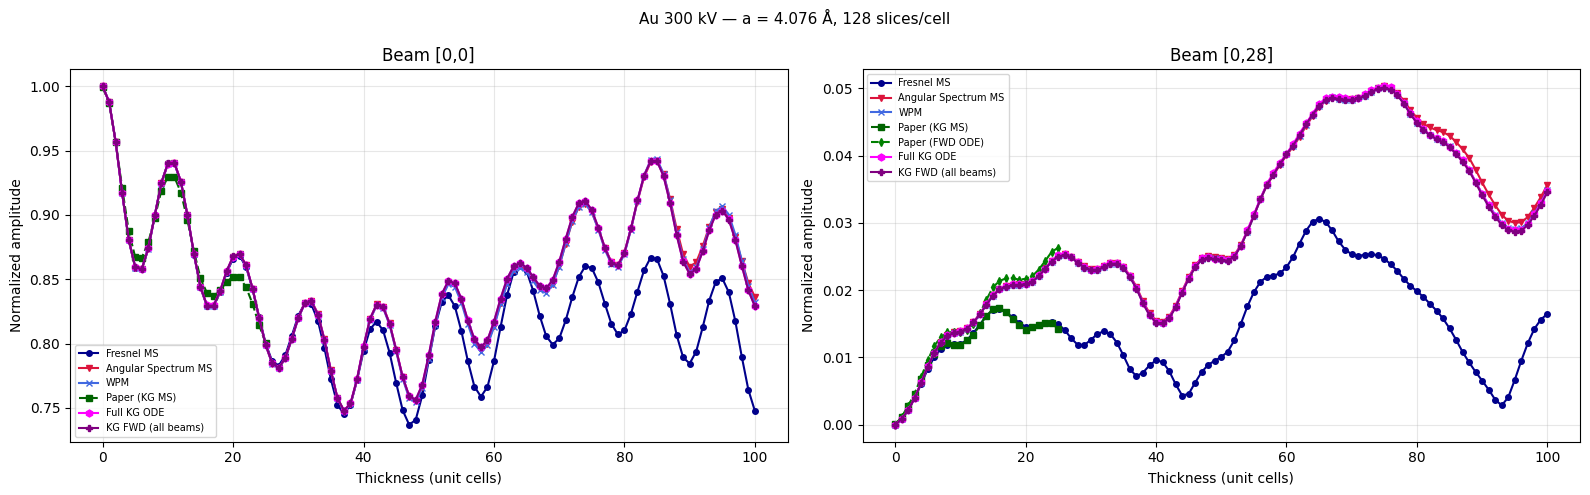

In [7]:
x = np.array(list(n_cells_range), dtype=float)

# Paper data only valid up to ~25 cells; restrict reference curves to that range
paper_max = 25
x_paper = x[x <= paper_max]
paper_00 = Beam_0_0_Au_Klein_Gordon_MS(x_paper)
paper_028_ms = Beam_0_28_Au_Klein_Gordon_MS(x_paper)
paper_028_fwd = Beam_0_28_Au_Klein_Gordon_FWD(x_paper)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# [0,0] beam
ax1.plot(x, beam_results['ms_00'], "o-", label="Fresnel MS", color="darkblue", ms=4)
ax1.plot(x, beam_results['as_00'], "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax1.plot(x, beam_results['wpm_00'], "x-", label="WPM", color="royalblue", ms=5)
ax1.plot(x_paper, paper_00, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax1.plot(x, kg_ode_00, "h-", label="Full KG ODE", color="magenta", ms=5)
ax1.plot(x, kg_all_00, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax1.set_xlabel("Thickness (unit cells)")
ax1.set_ylabel("Normalized amplitude")
ax1.set_title("Beam [0,0]")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=7)

# [0,28] beam
ax2.plot(x, beam_results['ms_028'], "o-", label="Fresnel MS", color="darkblue", ms=4)
ax2.plot(x, beam_results['as_028'], "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax2.plot(x, beam_results['wpm_028'], "x-", label="WPM", color="royalblue", ms=5)
ax2.plot(x_paper, paper_028_ms, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax2.plot(x_paper, paper_028_fwd, "d--", label="Paper (FWD ODE)", color="green", ms=4)
ax2.plot(x, kg_ode_028, "h-", label="Full KG ODE", color="magenta", ms=5)
ax2.plot(x, kg_all_028, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax2.set_xlabel("Thickness (unit cells)")
ax2.set_ylabel("Normalized amplitude")
ax2.set_title("Beam [0,28]")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=7)

fig.suptitle(f"Au 300 kV — a = {a_central} Å, {n_slices_per_cell} slices/cell", fontsize=11)
plt.tight_layout()
plt.show()

## RMSE summary

In [8]:
# ── Export figure for paper ──────────────────────────────────────────────────
import pathlib
paper_fig_dir = pathlib.Path('../../Paper/figures')
paper_fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(paper_fig_dir / 'Au_beam_amplitudes.pdf', bbox_inches='tight', dpi=300)
print(f'Saved → {paper_fig_dir / "Au_beam_amplitudes.pdf"}')

Saved → ../../Paper/figures/Au_beam_amplitudes.pdf


In [9]:
def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

# RMSE computed only over the paper data range (0–25 cells)
n_paper = int(paper_max) + 1

methods_00 = {
    "Fresnel MS": beam_results['ms_00'][:n_paper],
    "Angular Spectrum MS": beam_results['as_00'][:n_paper],
    "WPM": beam_results['wpm_00'][:n_paper],
    "Full KG ODE": kg_ode_00[:n_paper],
    "KG FWD (all beams)": kg_all_00[:n_paper],
}

methods_028 = {
    "Fresnel MS": beam_results['ms_028'][:n_paper],
    "Angular Spectrum MS": beam_results['as_028'][:n_paper],
    "WPM": beam_results['wpm_028'][:n_paper],
    "Full KG ODE": kg_ode_028[:n_paper],
    "KG FWD (all beams)": kg_all_028[:n_paper],
}

print(f"RMSE computed over 0–{paper_max} unit cells (paper data range)")
print(f"{'Method':<25s} {'[0,0] RMSE':>12s} {'[0,28] RMSE':>14s}")
print("-" * 53)
for name in methods_00:
    r00 = curve_rmse(methods_00[name], paper_00)
    r028 = curve_rmse(methods_028[name], paper_028_fwd)
    print(f"{name:<25s} {r00:>12.6f} {r028:>14.6f}")

RMSE computed over 0–25 unit cells (paper data range)
Method                      [0,0] RMSE    [0,28] RMSE
-----------------------------------------------------
Fresnel MS                    0.008174       0.005023
Angular Spectrum MS           0.008582       0.000815
WPM                           0.008401       0.000865
Full KG ODE                   0.008451       0.000777
KG FWD (all beams)            0.008502       0.000860


In [10]:
# ── LaTeX table for paper (Table 2) ──────────────────────────────────────────
print('% Paste into Paper/main.tex  →  tab:rmse_verification')
print(r'\begin{tabular}{lcc}')
print(r'    \hline')
print(r'    \textbf{Method} & \textbf{RMSE $[0,0]$} & \textbf{RMSE $[0,28]$} \\\\')
print(r'    \hline')
for name in methods_00:
    r00 = curve_rmse(methods_00[name], paper_00)
    r028 = curve_rmse(methods_028[name], paper_028_fwd)
    latex_name = name.replace('&', r'\&')
    print(f'    {latex_name:<25s} & {r00:.4e} & {r028:.4e} \\\\\\\\')
print(r'    \hline')
print(r'\end{tabular}')

% Paste into Paper/main.tex  →  tab:rmse_verification
\begin{tabular}{lcc}
    \hline
    \textbf{Method} & \textbf{RMSE $[0,0]$} & \textbf{RMSE $[0,28]$} \\\\
    \hline
    Fresnel MS                & 8.1744e-03 & 5.0227e-03 \\\\
    Angular Spectrum MS       & 8.5819e-03 & 8.1547e-04 \\\\
    WPM                       & 8.4011e-03 & 8.6465e-04 \\\\
    Full KG ODE               & 8.4509e-03 & 7.7708e-04 \\\\
    KG FWD (all beams)        & 8.5017e-03 & 8.5994e-04 \\\\
    \hline
\end{tabular}
